**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: 26/08/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.feature_engineering.ChemicalFeatureEngineering import ChemicalFeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.bags_compositions import ALL_SAMPLES
from config.elements_coefficients import RESISTIVITY_FACTORS, ENRICHMENT_FACTORS
from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()
chfe = ChemicalFeatureEngineering(
    all_samples=ALL_SAMPLES,
    resistivity_factors=RESISTIVITY_FACTORS,
    enrichment_factors=ENRICHMENT_FACTORS,
)



## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Experiment settings ----
ANNEALING_SCHEMA_DATE = "260826"
SN_SCHEMA_DATE = "190826"

VARIABLE = "iacs"
PROCESS = f"annealing_{VARIABLE}"
TAG = f"model_{PROCESS}_{ANNEALING_SCHEMA_DATE}_all-data"

# ---- Paths ----
FILE_NAME = f"dataset_{PROCESS}.csv"
FILE_NAME_SCHEMA_DATA = f"schema_annealing_essays_{ANNEALING_SCHEMA_DATE}.csv"
FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"
FILE_NAME_SN_COMPOSITION = f"serial-number-encoding_{SN_SCHEMA_DATE}.csv"


# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["initial_diameter", "IRI", "purity", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "best_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 1500

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.0 Chemical data

In [4]:
COLUMNS_TO_SELECT = [
    "experiment_id",
    "material_reference",
    "purity",
    "initial_diameter",
    "temperature",
    "time",
    "iacs",
    "tensile_strength",
    "elongation",
    "iacs_final",
    "tensile_strength_final",
    "elongation_final",
]

In [5]:
df_sn = pd.read_csv(os.path.join(varv.PATHS.data_structured, FILE_NAME_SN_COMPOSITION))
df_raw = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
df_nnan = df_raw.dropna(how="all")
df_feat = df_nnan[COLUMNS_TO_SELECT]
df_iri = chfe.add_features(df_feat, df_sn.drop(columns=["Sanity_check_Total"]))

In [96]:
df_sn

,ID,1A_sac1,1A_sac2,1B_sac1,1B_sac2,1B_sac3,1B_sac4,1B_sac5,1B_sac6,2N_sac1,2N_sac2,echantillon_2N,echantillon_1,echantillon_2,echantillon_3,echantillon_4,Sanity_check_Total
0,SN014,0.00,0.00,0.0000,1.0000,0.0000,0.00,0.0000,0.00,0.0000,0.0000,0.0000,0.000,0.000,0.000,0.000,1.0000
1,SN015,0.00,0.00,0.0000,0.4047,0.4047,0.00,0.1906,0.00,0.0000,0.0000,0.0000,0.000,0.000,0.000,0.000,1.0000
2,SN016,0.00,0.00,0.0000,0.2305,0.2305,0.00,0.2305,0.00,0.2305,0.0780,0.0000,0.000,0.000,0.000,0.000,1.0000
3,SN017,0.00,0.00,0.0205,0.2118,0.2118,0.00,0.2118,0.00,0.2118,0.1324,0.0000,0.000,0.000,0.000,0.000,1.0001
4,SN019,0.30,0.00,0.0000,0.0000,0.0000,0.00,0.0000,0.00,0.0000,0.6952,0.0048,0.000,0.000,0.000,0.000,1.0000
5,SN020,0.20,0.00,0.0000,0.0000,0.0000,0.00,0.0000,0.00,0.0000,0.7425,0.0575,0.000,0.000,0.000,0.000,1.0000
6,SN021,0.02,0.02,0.0000,0.0200,0.0200,0.00,0.0200,0.00,0.0000,0.8798,0.0202,0.000,0.000,0.000,0.000,1.0000
7,SN022,0.00,0.00,0.0000,0.0000,0.0000,0.00,0.0000,0.00,0.0000,0.0000,1.0000,0.000,0.000,0.000,0.000,1.0000
8,SN023,0.00,0.00,0.0000,0.0000,0.0000,0.00,0.0000,0.00,0.0000,0.0000,1.0000,0.000,0.000,0.000,0.000,1.0000
9,SN024,0.00,0.00,0.0000,0.0000,0.0000,0.00,0.0000,0.10,0.0000,0.0000,0.0000,0.225,0.225,0.225,0.225,1.0000


In [6]:
df_iri

,experiment_id,material_reference,purity,initial_diameter,temperature,time,iacs,tensile_strength,elongation,iacs_final,tensile_strength_final,elongation_final,IRI,GBEI
0,ANE_SN010_CD1_RS1_WP1_202602171500-1,C14500,99.9000,1.900000,623,30.0,88.260,NaN,NaN,88.350000,NaN,NaN,1.300000,0.489800
1,ANE_SN010_CD1_RS1_WP1_202602171430-1,C14500,99.9000,1.900000,623,60.0,88.260,NaN,NaN,88.655000,NaN,NaN,1.300000,0.489800
2,ANE_SN010_CD1_RS1_WP1_202602171400-1,C14500,99.9000,1.900000,623,90.0,88.260,NaN,NaN,88.800000,NaN,NaN,1.300000,0.489800
3,ANE_SN011_CD1_RS1_WP1_202602181507-1,Cu-ETP,99.9000,2.160000,573,30.0,99.825,391.690000,4.90%,102.340000,249.78,48.60%,0.195105,0.001038
4,ANE_SN011_CD1_RS1_WP1_202603301900-1,Cu-ETP,99.9000,2.182333,573,30.0,99.390,387.595254,6.02%,102.230000,255.01,56.21%,0.195105,0.001038
5,ANE_SN011_CD1_RS1_WP1_202603311135-1,Cu-ETP,99.9000,2.182333,588,30.0,99.390,387.595254,6.02%,101.346667,NaN,NaN,0.195105,0.001038
6,ANE_SN011_CD1_RS1_WP1_202604031750-1,Cu-ETP,99.9000,2.191700,573,30.0,99.230,404.662322,3.53%,101.355000,NaN,NaN,0.195105,0.001038
7,ANE_SN011_CD1_RS1_WP1_202604031750-2,Cu-ETP,99.9000,2.196300,573,30.0,98.720,411.951845,3.27%,101.480000,NaN,NaN,0.195105,0.001038
8,ANE_CHIMIE_PARIS,Cu-T2,99.9000,1.200000,523,30.0,97.710,431.580000,0.94%,100.290000,247.08,20.15%,0.233275,0.002674
9,ANE_CHIMIE_PARIS,Cu-T2,99.9000,1.200000,523,60.0,97.710,431.580000,0.94%,100.420000,242.21,22.04%,0.233275,0.002674


## 2.1 Schema data

In [7]:
df, df_val = proc.process_annealing_iacs(
    features=FEATURES,
    target=TARGET,
    df_schema=df_iri,
)

In [8]:
df

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final
0,1.900000,1.300000,99.9000,88.260,623,30.0,88.350000
1,1.900000,1.300000,99.9000,88.260,623,60.0,88.655000
2,1.900000,1.300000,99.9000,88.260,623,90.0,88.800000
3,2.160000,0.195105,99.9000,99.825,573,30.0,102.340000
4,2.182333,0.195105,99.9000,99.390,573,30.0,102.230000
5,2.182333,0.195105,99.9000,99.390,588,30.0,101.346667
6,2.191700,0.195105,99.9000,99.230,573,30.0,101.355000
7,2.196300,0.195105,99.9000,98.720,573,30.0,101.480000
8,1.200000,0.233275,99.9000,97.710,523,30.0,100.290000
9,1.200000,0.233275,99.9000,97.710,523,60.0,100.420000


## 2.2 Validation data

In [9]:
df_val

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final
27,1.200000,0.402535,99.9800,102.700,523,30.0,102.235
40,2.000000,0.454239,99.9558,97.400,723,60.0,101.620
26,1.200000,0.402535,99.9800,102.700,573,90.0,103.935
43,2.000000,0.462318,99.7260,95.610,723,60.0,102.480
24,1.200000,0.402535,99.9800,102.700,573,30.0,103.295
37,0.800000,0.419799,99.9740,97.565,873,30.0,98.355
12,1.200000,0.233275,99.9000,97.710,573,60.0,101.350
19,1.200000,0.195105,99.9000,101.220,573,60.0,104.835
4,2.182333,0.195105,99.9000,99.390,573,30.0,102.230


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [10]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.93 GB / 31.57 GB (31.5%)
Disk Space Avail:   696.14 GB / 932.08 GB (74.7%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 1500s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_annealing_iacs_260826_all-data\model_a"
Train Data Rows:    48
Train Data Columns: 6
Label Column:       iacs_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-val

In [11]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.739865,root_mean_squared_error,0.091789,41.956553,0.000000,0.007811,2,True,107
1,NeuralNetTorch_BAG_L1,-0.790493,root_mean_squared_error,0.029520,7.166399,0.029520,7.166399,1,True,8
2,NeuralNetTorch_r135_BAG_L1,-0.806983,root_mean_squared_error,0.032196,7.187813,0.032196,7.187813,1,True,93
3,NeuralNetTorch_r86_BAG_L1,-0.837006,root_mean_squared_error,0.034281,7.307345,0.034281,7.307345,1,True,28
4,NeuralNetTorch_r71_BAG_L1,-0.848609,root_mean_squared_error,0.042979,7.107710,0.042979,7.107710,1,True,69
...,...,...,...,...,...,...,...,...,...,...
102,LightGBM_r135_BAG_L1,-3.683024,root_mean_squared_error,0.002004,1.272963,0.002004,1.272963,1,True,78
103,LightGBM_r143_BAG_L1,-3.683024,root_mean_squared_error,0.003337,1.417957,0.003337,1.417957,1,True,53
104,LightGBM_r130_BAG_L1,-3.683024,root_mean_squared_error,0.004018,0.947778,0.004018,0.947778,1,True,27
105,ExtraTrees_r4_BAG_L1,-3.695014,root_mean_squared_error,0.037608,0.482909,0.037608,0.482909,1,True,62


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [12]:
# aml_h2o = modl.fit_h2o_automl(
#     df= df,
#     target= TARGET,
#     features= FEATURES,
#     weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
#     num_bag_folds= NUM_BAG_FOLDS_A,
#     use_shared_folds= USE_SHARED_FOLDS,
#     time_limit= TIME_LIMIT_A
# )

In [13]:
# aml_h2o.leaderboard

In [14]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [15]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = np.abs(df[TARGET] - mu_oof)
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(48,)  any NaN? False


## 4.1 fast check on big residuals

In [16]:
df_verification = pd.concat(
    [df[FEATURES + [TARGET]],
     mu_oof.rename(f"{TARGET}_pred"),
     residuals_oof.rename("residual_abs")], axis=1
)

df_verification.sort_values(by="residual_abs", ascending=False)


,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final,iacs_final_pred,residual_abs
25,1.200000,0.402535,99.9800,102.700,573,60.0,100.785000,103.014313,2.229313
38,0.800000,0.419799,99.9740,97.565,673,30.0,101.180000,99.317619,1.862381
30,2.000000,0.419799,99.9740,99.650,673,30.0,102.675000,100.925644,1.749356
27,1.200000,0.402535,99.9800,102.700,523,30.0,102.235000,103.441689,1.206689
10,1.200000,0.233275,99.9000,97.710,523,90.0,100.290000,101.384926,1.094926
26,1.200000,0.402535,99.9800,102.700,573,90.0,103.935000,102.953728,0.981272
11,1.200000,0.233275,99.9000,97.710,573,30.0,101.350000,100.402275,0.947725
19,1.200000,0.195105,99.9000,101.220,573,60.0,104.835000,103.900764,0.934236
43,2.000000,0.462318,99.7260,95.610,723,60.0,102.480000,101.548866,0.931134
17,1.200000,0.195105,99.9000,100.250,573,30.0,102.755000,103.680252,0.925252


## 4.2 Recovering weights 

In [17]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (106, 48)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_r177_BAG_L1', 'NeuralNetTorch_r79_BAG_L1', 'LightGBM_r131_BAG_L1', 'NeuralNetFastAI_r191_BAG_L1', 'CatBoost_r9_BAG_L1', 'LightGBM_r96_BAG_L1', 'NeuralNetTorch_r22_BAG_L1', 'XGBoost_r33_BAG_L1', 'ExtraTrees_r42_BAG_L1', 'CatBoost_r137_BAG_L1', 'NeuralNetFastAI_r102_BAG_L1', 'CatBoost_r13_BAG_L1', 'RandomForest_r195_BAG_L1', 'LightGBM_r188_BAG_L1', 'NeuralNetFastAI_r145_BAG_L1', 'XGBoost_r89_BAG_L1', 'NeuralNetTorch_r30_BAG_L1', 'LightGBM_r130_BAG_L1', 'NeuralNetTorch_r86_BAG_L1', 'CatBoost_r50_BAG_L1', 'NeuralNetFastAI_r11_BAG_L1', 'XGBoost_r194_BAG_L1', 'ExtraTrees_r172_BAG_L1', 'CatBoost_r69_BAG_L1', 'NeuralNetFastAI_r103_BAG_L1', 'NeuralNetTorch_r14_BAG_L1', 'LightGBM_r161_BAG_L1', 'NeuralNetFastAI_r143_BA

In [18]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000004  (OK)

Non-zero weights:
  NeuralNetTorch_BAG_L1           0.5238
  LightGBMLarge_BAG_L1            0.0952
  NeuralNetFastAI_r134_BAG_L1     0.2381
  XGBoost_r22_BAG_L1              0.0952
  CatBoost_r163_BAG_L1            0.0476


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [19]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    4.800000e+01
mean     1.118362e-06
std      1.034346e-06
min      1.162928e-08
25%      3.692585e-07
50%      8.389881e-07
75%      1.553110e-06
max      4.235035e-06
Name: iacs_final, dtype: float64

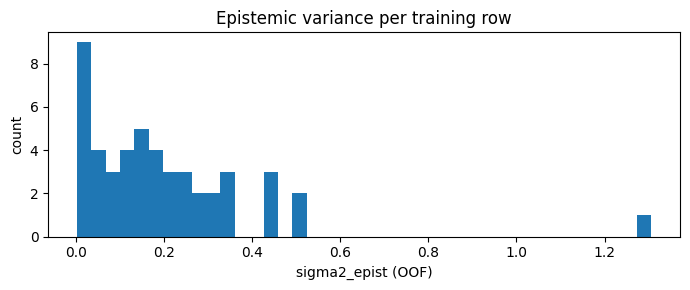

In [20]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [21]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    48.000000
mean      0.494814
std       0.587521
min       0.002289
25%       0.160345
50%       0.341057
75%       0.623688
max       2.671181
Name: iacs_final, dtype: float64

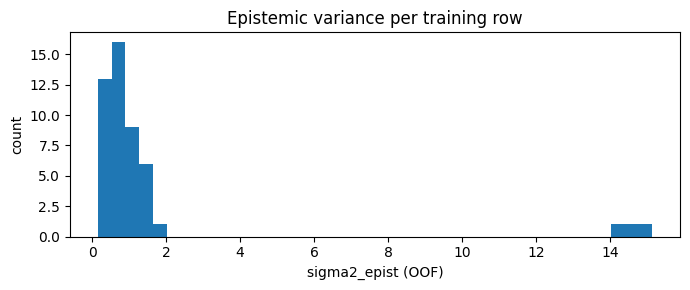

In [22]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [23]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 48
  n_truncated          = 22
  pct_truncated        = 45.833333333333336
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 4.787430196856614
  r_tilde_sq_mean      = 0.42407673919358474
  r_tilde_sq_median    = 0.01971428655498675


In [24]:
r_tilde_sq

array([0.        , 0.        , 0.        , 0.        , 0.6188104 ,
       0.        , 0.        , 0.        , 0.04372056, 0.        ,
       0.95803953, 0.87962021, 0.38729887, 0.        , 0.        ,
       0.        , 0.08106243, 0.65716921, 0.06213559, 0.77226498,
       0.02293261, 0.03698122, 0.48796103, 0.        , 0.27772795,
       4.7874302 , 0.68185691, 1.4150424 , 0.        , 0.        ,
       2.61761602, 0.45864632, 0.        , 0.        , 0.        ,
       0.        , 0.11025916, 0.        , 3.45082608, 0.        ,
       0.49027818, 0.14074685, 0.01649597, 0.74628524, 0.        ,
       0.0094131 , 0.14506248, 0.        ])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [25]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.40 GB / 31.57 GB (29.8%)
Disk Space Avail:   695.84 GB / 932.08 GB (74.7%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_annealing_iacs_260826_all-data\model_b"
Train Data Rows:    48
Train Data Columns: 6
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (1.5659939829897327, -13.8155105579

In [26]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-6.062416,root_mean_squared_error,0.040349,7.395749,0.008120,0.000000,2,True,10
1,NeuralNetFastAI_BAG_L1,-6.068553,root_mean_squared_error,0.027690,6.780198,0.027690,6.780198,1,True,6
2,LightGBMLarge_BAG_L1,-6.226618,root_mean_squared_error,0.004539,0.615551,0.004539,0.615551,1,True,9
3,CatBoost_BAG_L1,-6.276908,root_mean_squared_error,0.011937,1.277068,0.011937,1.277068,1,True,4
4,XGBoost_BAG_L1,-6.368522,root_mean_squared_error,0.021010,0.558067,0.021010,0.558067,1,True,7
5,NeuralNetTorch_BAG_L1,-6.394564,root_mean_squared_error,0.041125,6.152813,0.041125,6.152813,1,True,8
6,LightGBMXT_BAG_L1,-6.398138,root_mean_squared_error,0.000000,0.584801,0.000000,0.584801,1,True,1
7,LightGBM_BAG_L1,-6.398138,root_mean_squared_error,0.004341,0.530011,0.004341,0.530011,1,True,2
8,ExtraTreesMSE_BAG_L1,-7.777971,root_mean_squared_error,0.038741,0.475715,0.038741,0.475715,1,True,5
9,RandomForestMSE_BAG_L1,-7.798986,root_mean_squared_error,0.035677,0.571240,0.035677,0.571240,1,True,3


In [27]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    "iacs": df["iacs"],
    "iacs_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,iacs,iacs_final
0,0.396994,-11.394924,0.178499,88.260,88.350000
1,0.135726,-10.510217,0.077121,88.260,88.655000
2,0.187961,-6.007246,0.347023,88.260,88.800000
3,0.222866,-7.279229,0.257571,99.825,102.340000
4,0.787945,-7.009728,0.002047,99.390,102.230000
5,0.396215,-7.175633,0.171795,99.390,101.346667
6,0.054333,-10.006069,0.140300,99.230,101.355000
7,0.235562,-10.058866,0.184390,98.720,101.480000
8,0.291816,-7.336013,0.041436,97.710,100.290000
9,0.007914,-7.392386,0.204057,97.710,100.420000


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [28]:
df[TARGET].var()

np.float64(13.322320419396622)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [29]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.416667,-0.083333
1,0.80,0.687500,-0.112500
2,0.90,0.791667,-0.108333
3,0.95,0.875000,-0.075000


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [30]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 1.3156

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.541667,0.041667
1,0.80,0.812500,0.012500
2,0.90,0.895833,-0.004167
3,0.95,0.937500,-0.012500


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [31]:
c_opt
weights

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.23808991e-01,
       9.52376134e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 9.48031311e-08,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.12838292e-06, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.65705643e-07, 0.00000000e+00, 1.27653503e-07,
       1.68540768e-07, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 8.01818607e-08, 7.36187350e-08, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.37621168e-06, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 2.38095086e-01, 0.00000000e+00,
      

In [32]:
len(base_model_names)
len(weights)

106

In [33]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df_val, # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df_val, #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 0.5799, 'mae': 0.5267, 'mape': 0.5126, 'r2': 0.8881}
coverage: {0.5: 0.333, 0.8: 1.0, 0.9: 1.0, 0.95: 1.0}


In [35]:
# ---- Target-agnostic point prediction from a plain dict ----
single = modl.predict_target(
    predictor_a,
    {
        "initial_diameter": 2.2,
        "purity": 99.7036,
        "IRI": 0.525991,
        "iacs": 94.84,
        "temperature": 723.0,
        "time": 60.0,
    },
)
print(f"Predicted {TARGET}: {single[0]:.3f}")

Predicted iacs_final: 100.435


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [36]:
df.head(5)

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final
0,1.900000,1.300000,99.9,88.260,623,30.0,88.350
1,1.900000,1.300000,99.9,88.260,623,60.0,88.655
2,1.900000,1.300000,99.9,88.260,623,90.0,88.800
3,2.160000,0.195105,99.9,99.825,573,30.0,102.340
4,2.182333,0.195105,99.9,99.390,573,30.0,102.230


In [37]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,88.710811,0.011072,0.133223,0.249747,0.499747,88.710808,1.053528,88.710811,0.499747,0.000000e+00
1,88.804829,0.023581,0.133223,0.271397,0.520958,88.804825,1.000000,88.804829,0.520958,0.000000e+00
2,88.949623,0.109119,0.133223,0.419448,0.647648,88.949623,1.050250,88.949623,0.647648,0.000000e+00
3,101.908545,0.109203,0.133223,0.419592,0.647759,101.908546,1.000000,101.908542,0.647752,9.095878e-07
4,101.660352,0.054721,0.133223,0.325295,0.570346,101.660355,1.000000,101.660352,0.570346,2.378237e-09


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [38]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_iacs\model_annealing_iacs_260826_all-data\artifacts.pkl


In [39]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "ANNEALING_SCHEMA_DATE": ANNEALING_SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_iacs\model_annealing_iacs_260826_all-data\global_config.txt


In [40]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
# h2o_oof_preds = (
#     aml_h2o.leader.cross_validation_holdout_predictions()
#     .as_data_frame()
#     .iloc[:, 0]
#     .to_numpy()
# )

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
# metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        # {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
# leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
# leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  0.739865  0.559145  0.551859  0.958037
Saved to: ../../models/annealing_iacs\model_annealing_iacs_260826_all-data


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [41]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: iacs_final
Features: ['initial_diameter', 'IRI', 'purity', 'iacs', 'temperature', 'time']


In [42]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,88.710811,0.011072,0.133223,0.249747,0.499747,88.710808,1.053528,88.710811,0.499747,0.000000e+00
1,88.804829,0.023581,0.133223,0.271397,0.520958,88.804825,1.000000,88.804829,0.520958,0.000000e+00
2,88.949623,0.109119,0.133223,0.419448,0.647648,88.949623,1.050250,88.949623,0.647648,0.000000e+00
3,101.908545,0.109203,0.133223,0.419592,0.647759,101.908546,1.000000,101.908542,0.647752,9.095878e-07
4,101.660352,0.054721,0.133223,0.325295,0.570346,101.660355,1.000000,101.660352,0.570346,2.378237e-09


In [43]:
# ---- 4) Target-agnostic quick prediction from a plain dict ----
# Works for any predictor/target via modl.predict_target (features inferred
# from the predictor when not passed explicitly).
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {
        "initial_diameter": 2.2,
        "purity": 99.7036,
        "IRI": 0.525991,
        "iacs": 94.84,
        "temperature": 723.0,
        "time": 60.0,
    },
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 100.435


In [44]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.


# 12 Adhoc running

In [45]:
IACS_TAG_DIR = EXPERIMENT_DIR
UTS_TAG_DIR = os.path.join(
    varv.PATHS.models, "annealing_uts", "experiments", "annealing-uts-v1-best_quality"
)
ELONGATION_TAG_DIR = os.path.join(
    varv.PATHS.models, "annealing_elongation", "experiments", "annealing-schema230726"
)

In [70]:
single_loaded = modl.predict_target(
    predictor_a_loaded,
    {
        "initial_diameter": 2.2,
        "purity": 99.7036,
        "IRI": 0.525991,
        "iacs": 94.84,
        "temperature": 500.0 + 273,
        "time": 100.0,
    },
    features=loaded_artifacts["features"],
)
print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

Predicted iacs_final: 101.915


In [58]:
from src.modeling.MBCInference import MBCInference

mbc = MBCInference(modl, load)

MATERIAL_PROPERTIES = {
    "initial_diameter": 2.2,
    "purity": 99.7036,
    "IRI": 0.525991,
    "iacs": 94.84,
    "tensile_strength": 362.31,
    "elongation": 6.65,
}

# ---- Grid (inclusive of upper bound, like the deterministic build_param_grid) ----
OPERATIONAL_LIMITS = {
    "temperature": [200+273, 600 + 273],  # Kelvin
    "time": [30, 120],  # minutes
}
STEP = {"temperature": 10, "time": 5}

In [59]:
down_bundles = mbc.load_surrogates_best(
    {
        "iacs": IACS_TAG_DIR,
        "uts": UTS_TAG_DIR,
        "elongation": ELONGATION_TAG_DIR
    },
     metric="rmse",
)

In [60]:
param_grid = mbc.build_param_grid(OPERATIONAL_LIMITS, STEP)
df_grid = mbc.build_state_grid_df(MATERIAL_PROPERTIES, param_grid)

print(f"Grid: {len(param_grid['temperature'])} temperatures x "
      f"{len(param_grid['time'])} times = {len(df_grid)} cells")
df_grid.head()

Grid: 41 temperatures x 19 times = 779 cells


,initial_diameter,purity,IRI,iacs,tensile_strength,elongation,temperature,time
0,2.2,99.7036,0.525991,94.84,362.31,6.65,473,30
1,2.2,99.7036,0.525991,94.84,362.31,6.65,473,35
2,2.2,99.7036,0.525991,94.84,362.31,6.65,473,40
3,2.2,99.7036,0.525991,94.84,362.31,6.65,473,45
4,2.2,99.7036,0.525991,94.84,362.31,6.65,473,50


In [61]:
df_pred = mbc.predict_all(down_bundles, df_grid, ood_gamma=1.0)


In [62]:
df_pred

,initial_diameter,purity,IRI,iacs,tensile_strength,elongation,temperature,time,iacs_mu,iacs_sigma,...,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max,elongation_mu,elongation_sigma,elongation_sigma2_epist,elongation_sigma2_aleat,elongation_ood_multiplier
0,2.2,99.7036,0.525991,94.84,362.31,6.65,473,30,96.939134,1.221426,...,364.319336,1.0,272.465054,16.683703,0.0,49.469179,7.715772,11.769248,1.821305,2.117084
1,2.2,99.7036,0.525991,94.84,362.31,6.65,473,35,97.045966,1.152748,...,364.319336,1.0,272.386453,16.696525,0.0,49.473471,7.744768,11.871587,1.821305,2.120265
2,2.2,99.7036,0.525991,94.84,362.31,6.65,473,40,97.152052,1.088848,...,364.319336,1.0,272.375846,16.696829,0.0,49.480145,7.792236,12.039951,1.821305,2.125913
3,2.2,99.7036,0.525991,94.84,362.31,6.65,473,45,97.266559,1.023459,...,364.319336,1.0,272.366555,16.697043,0.0,49.488364,7.854624,12.262798,1.821305,2.134009
4,2.2,99.7036,0.525991,94.84,362.31,6.65,473,50,97.462687,1.087413,...,364.319336,1.0,275.178311,17.438703,0.0,48.910458,10.269922,22.256264,1.821305,2.144524
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
774,2.2,99.7036,0.525991,94.84,362.31,6.65,873,100,102.185047,2.108499,...,364.319336,1.0,212.811658,21.094022,0.0,54.447611,4.548700,2.902076,1.821305,2.115799
775,2.2,99.7036,0.525991,94.84,362.31,6.65,873,105,102.261502,2.220518,...,364.319336,1.0,212.807654,21.106613,0.0,54.449747,4.572002,2.950594,1.821305,2.139481
776,2.2,99.7036,0.525991,94.84,362.31,6.65,873,110,102.336131,2.338092,...,364.319336,1.0,213.656125,21.149596,0.0,54.452864,4.594316,2.997286,1.821305,2.165330
777,2.2,99.7036,0.525991,94.84,362.31,6.65,873,115,102.403681,2.456325,...,364.319336,1.0,213.652428,21.162040,0.0,54.457409,4.613625,3.037875,1.821305,2.193270


In [66]:
df_pred.to_csv(os.path.join(varv.PATHS.data_enriched, f"annealing_predictions_all_{ANNEALING_SCHEMA_DATE}.csv"))

In [64]:
df_pred.sort_values(by="iacs_mu", ascending=False).head(15)

,initial_diameter,purity,IRI,iacs,tensile_strength,elongation,temperature,time,iacs_mu,iacs_sigma,...,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max,elongation_mu,elongation_sigma,elongation_sigma2_epist,elongation_sigma2_aleat,elongation_ood_multiplier
778,2.2,99.7036,0.525991,94.84,362.31,6.65,873,120,102.466534,2.577764,...,364.319336,1.0,213.629737,21.445369,0.0,54.463305,4.629842,3.072096,1.821305,2.223222
777,2.2,99.7036,0.525991,94.84,362.31,6.65,873,115,102.403681,2.456325,...,364.319336,1.0,213.652428,21.162040,0.0,54.457409,4.613625,3.037875,1.821305,2.193270
776,2.2,99.7036,0.525991,94.84,362.31,6.65,873,110,102.336131,2.338092,...,364.319336,1.0,213.656125,21.149596,0.0,54.452864,4.594316,2.997286,1.821305,2.165330
759,2.2,99.7036,0.525991,94.84,362.31,6.65,863,120,102.328133,2.254950,...,364.319336,1.0,213.199473,21.631983,0.0,54.462427,4.581731,2.970923,1.821305,2.183709
740,2.2,99.7036,0.525991,94.84,362.31,6.65,853,120,102.312021,2.191409,...,364.319336,1.0,212.649529,21.833222,0.0,54.461558,4.536061,2.875863,1.821305,2.145964
721,2.2,99.7036,0.525991,94.84,362.31,6.65,843,120,102.300156,2.135962,...,364.319336,1.0,212.334229,22.009588,0.0,54.460642,4.493142,2.787397,1.821305,2.110082
702,2.2,99.7036,0.525991,94.84,362.31,6.65,833,120,102.288347,2.083392,...,364.319336,1.0,211.953920,22.159279,0.0,54.459691,4.453009,2.705435,1.821305,2.076161
664,2.2,99.7036,0.525991,94.84,362.31,6.65,813,120,102.286064,1.953054,...,364.319336,1.0,208.848914,22.013965,0.0,54.457645,4.381607,2.561431,1.821305,2.014590
645,2.2,99.7036,0.525991,94.84,362.31,6.65,803,120,102.278803,1.912816,...,364.319336,1.0,208.451715,22.027686,0.0,54.456524,4.350600,2.499619,1.821305,1.987135
683,2.2,99.7036,0.525991,94.84,362.31,6.65,823,120,102.277273,2.033359,...,364.319336,1.0,210.984321,22.158489,0.0,54.458690,4.415809,2.630118,1.821305,2.044298


In [65]:
df_pred[df_pred["time"] == 60].sort_values(by="iacs_mu", ascending=False)

,initial_diameter,purity,IRI,iacs,tensile_strength,elongation,temperature,time,iacs_mu,iacs_sigma,...,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max,elongation_mu,elongation_sigma,elongation_sigma2_epist,elongation_sigma2_aleat,elongation_ood_multiplier
766,2.2,99.7036,0.525991,94.84,362.31,6.65,873,60,101.365178,1.484527,...,364.319336,1.0,213.345798,20.046852,0.0,54.623600,4.926264,3.718746,1.821305,2.012111
747,2.2,99.7036,0.525991,94.84,362.31,6.65,863,60,100.919097,0.932956,...,364.319336,1.0,212.907466,20.230493,0.0,54.622799,4.850055,3.548663,1.821305,1.963804
728,2.2,99.7036,0.525991,94.84,362.31,6.65,853,60,100.870137,0.884161,...,364.319336,1.0,212.319127,20.475570,0.0,54.621952,4.777031,3.388177,1.821305,1.917074
709,2.2,99.7036,0.525991,94.84,362.31,6.65,843,60,100.833873,0.849787,...,364.319336,1.0,211.833827,20.721139,0.0,54.621054,4.707355,3.237318,1.821305,1.872039
690,2.2,99.7036,0.525991,94.84,362.31,6.65,833,60,100.802011,0.824186,...,364.319336,1.0,211.295741,20.978621,0.0,54.620116,4.641152,3.096032,1.821305,1.828824
652,2.2,99.7036,0.525991,94.84,362.31,6.65,813,60,100.776677,0.766851,...,364.319336,1.0,208.241357,21.294304,0.0,54.618142,4.519735,2.842113,1.821305,1.748389
671,2.2,99.7036,0.525991,94.84,362.31,6.65,823,60,100.773746,0.803159,...,364.319336,1.0,210.257396,21.161129,0.0,54.619157,4.578521,2.964211,1.821305,1.787561
633,2.2,99.7036,0.525991,94.84,362.31,6.65,803,60,100.761602,0.759023,...,364.319336,1.0,207.673753,21.400380,0.0,54.617045,4.465035,2.729918,1.821305,1.711452
614,2.2,99.7036,0.525991,94.84,362.31,6.65,793,60,100.744489,0.754362,...,364.319336,1.0,207.094664,21.455336,0.0,54.615849,4.414628,2.627739,1.821305,1.676895
595,2.2,99.7036,0.525991,94.84,362.31,6.65,783,60,100.727995,0.749364,...,364.319336,1.0,206.548757,21.504102,0.0,54.614566,4.368633,2.535514,1.821305,1.644871


In [72]:
df_verification.shape

(48, 9)

In [74]:
df_analysis = df_verification.copy()
df_analysis["iacs_percentual"] = df_analysis["iacs_final"] / df_analysis["iacs"]
df_analysis["iacs_diff"] = df_analysis["iacs_final"] - df_analysis["iacs"]

df_analysis["iacs_percentual_expected"] = df_analysis["iacs_final_pred"] / df_analysis["iacs"]
df_analysis["iacs_diff_expected"] =  df_analysis["iacs_final_pred"] - df_analysis["iacs"]

In [76]:
df_analysis.columns

Index(['initial_diameter', 'IRI', 'purity', 'iacs', 'temperature', 'time',
       'iacs_final', 'iacs_final_pred', 'residual_abs', 'iacs_percentual',
       'iacs_diff', 'iacs_percentual_expected', 'iacs_diff_expected'],
      dtype='object')

In [75]:
df_analysis

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final,iacs_final_pred,residual_abs,iacs_percentual,iacs_diff,iacs_percentual_expected,iacs_diff_expected
0,1.900000,1.300000,99.9000,88.260,623,30.0,88.350000,88.746994,0.396994,1.001020,0.090000,1.005518,0.486994
1,1.900000,1.300000,99.9000,88.260,623,60.0,88.655000,88.790726,0.135726,1.004475,0.395000,1.006013,0.530726
2,1.900000,1.300000,99.9000,88.260,623,90.0,88.800000,88.987961,0.187961,1.006118,0.540000,1.008248,0.727961
3,2.160000,0.195105,99.9000,99.825,573,30.0,102.340000,102.117134,0.222866,1.025194,2.515000,1.022962,2.292134
4,2.182333,0.195105,99.9000,99.390,573,30.0,102.230000,101.442055,0.787945,1.028574,2.840000,1.020646,2.052055
5,2.182333,0.195105,99.9000,99.390,588,30.0,101.346667,101.742882,0.396215,1.019687,1.956667,1.023673,2.352882
6,2.191700,0.195105,99.9000,99.230,573,30.0,101.355000,101.300667,0.054333,1.021415,2.125000,1.020867,2.070667
7,2.196300,0.195105,99.9000,98.720,573,30.0,101.480000,101.244438,0.235562,1.027958,2.760000,1.025572,2.524438
8,1.200000,0.233275,99.9000,97.710,523,30.0,100.290000,99.998184,0.291816,1.026405,2.580000,1.023418,2.288184
9,1.200000,0.233275,99.9000,97.710,523,60.0,100.420000,100.412086,0.007914,1.027735,2.710000,1.027654,2.702086


,temperature,metric,n,spearman,p_value,slope_log_time
0,523,iacs_final,9,0.1588,0.6833,0.5172
1,523,iacs_diff,9,0.1588,0.6833,0.5172
2,523,iacs_percentual,9,0.1588,0.6833,0.0051
3,523,delta_rho,9,-0.1588,0.6833,-0.0000
4,523,residual_signed,9,0.0000,1.0000,0.0476
5,573,iacs_final,17,0.0777,0.7669,0.8566
6,573,iacs_diff,17,0.0680,0.7954,-0.0546
7,573,iacs_percentual,17,0.0777,0.7669,-0.0006
8,573,delta_rho,17,-0.0777,0.7669,0.0000
9,573,residual_signed,17,0.0874,0.7388,-0.0468


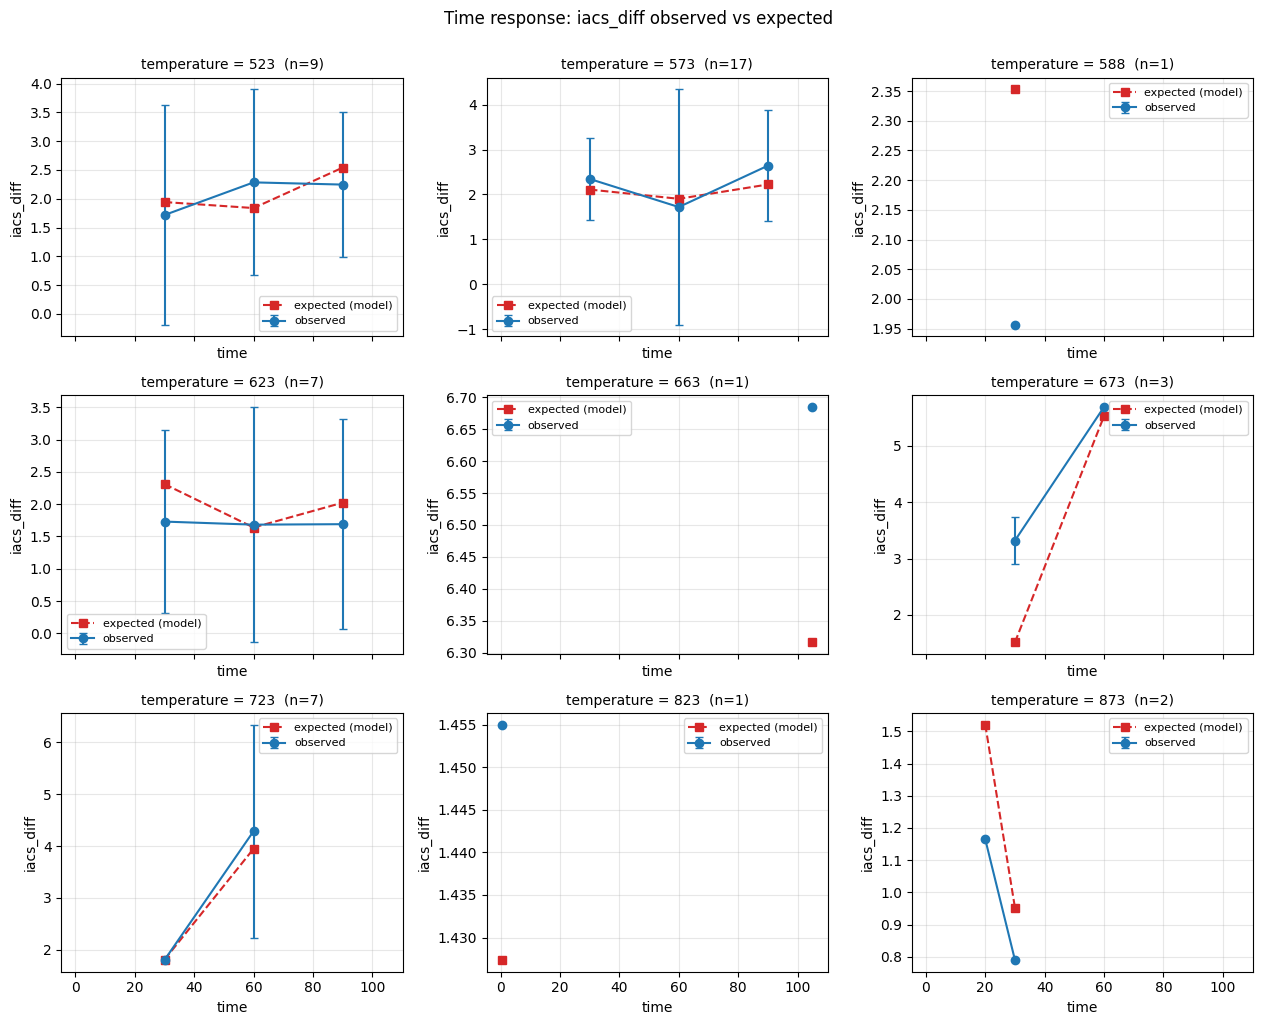

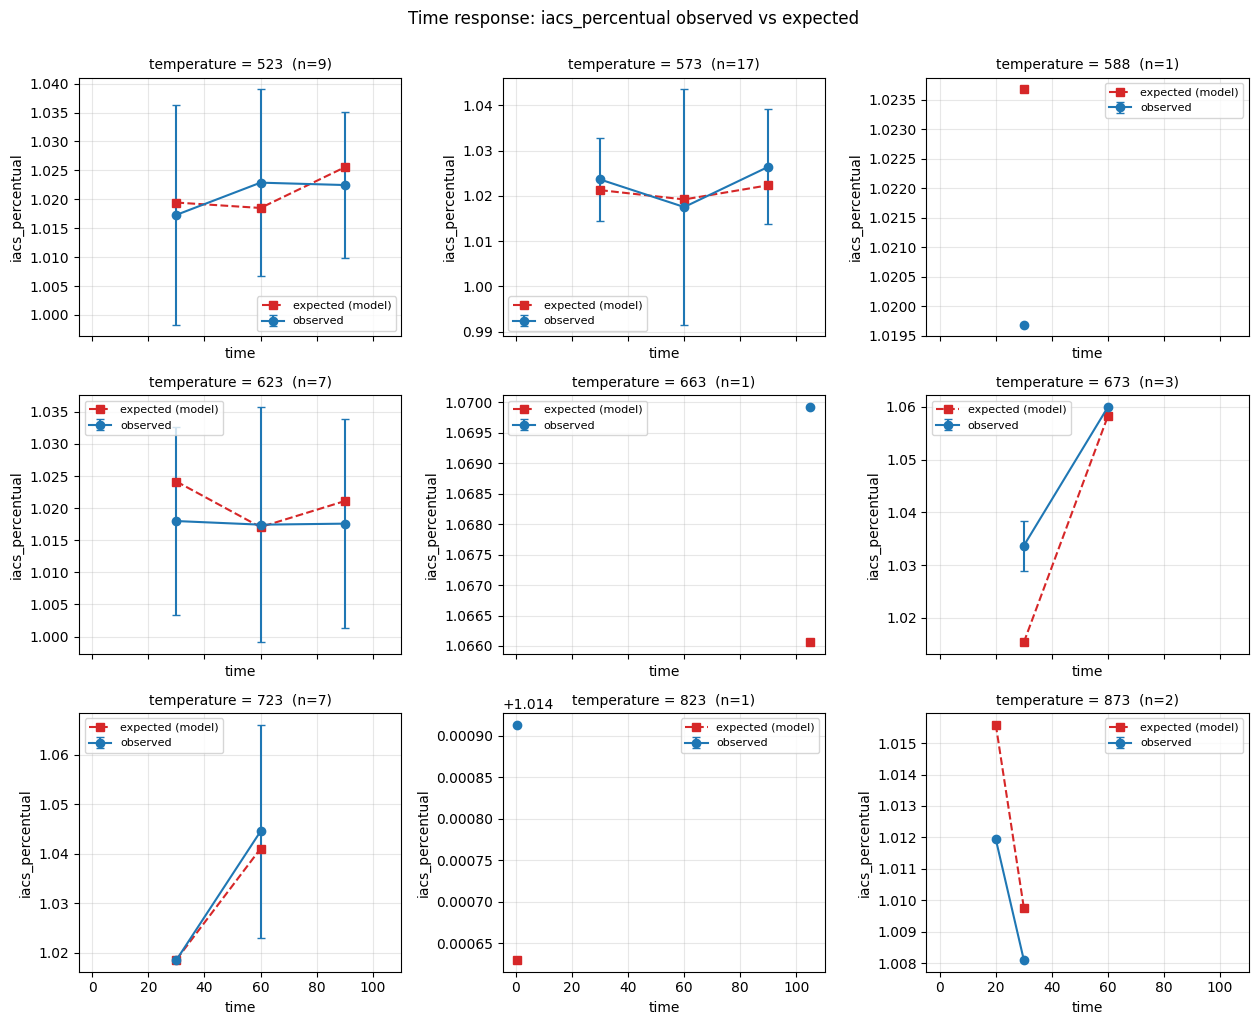

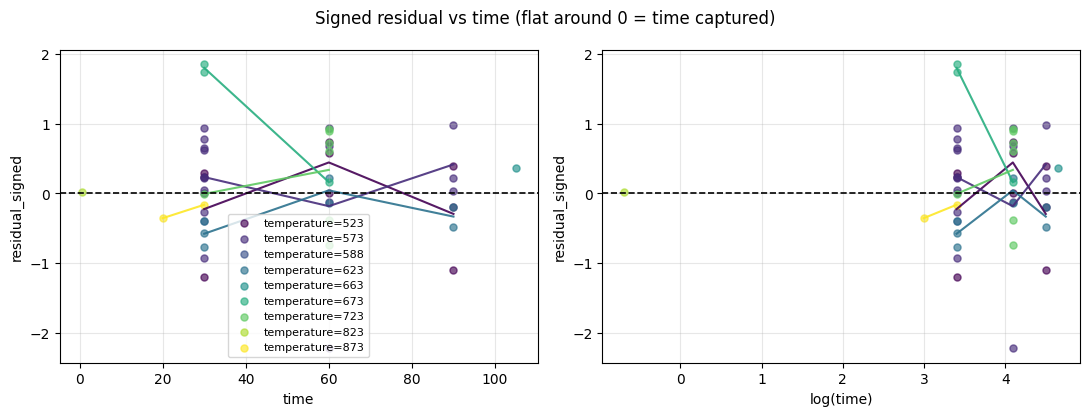

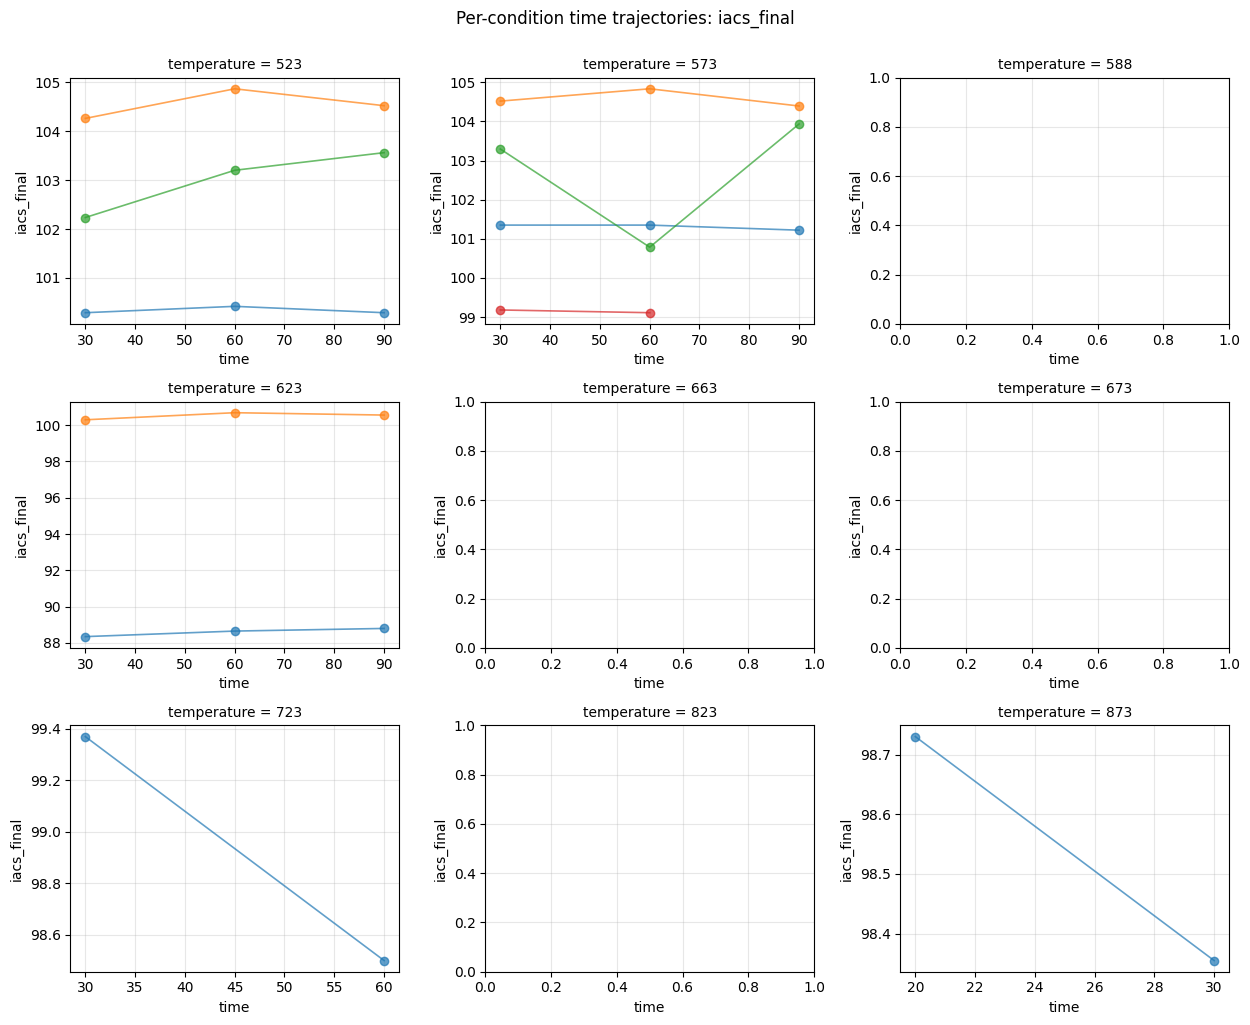

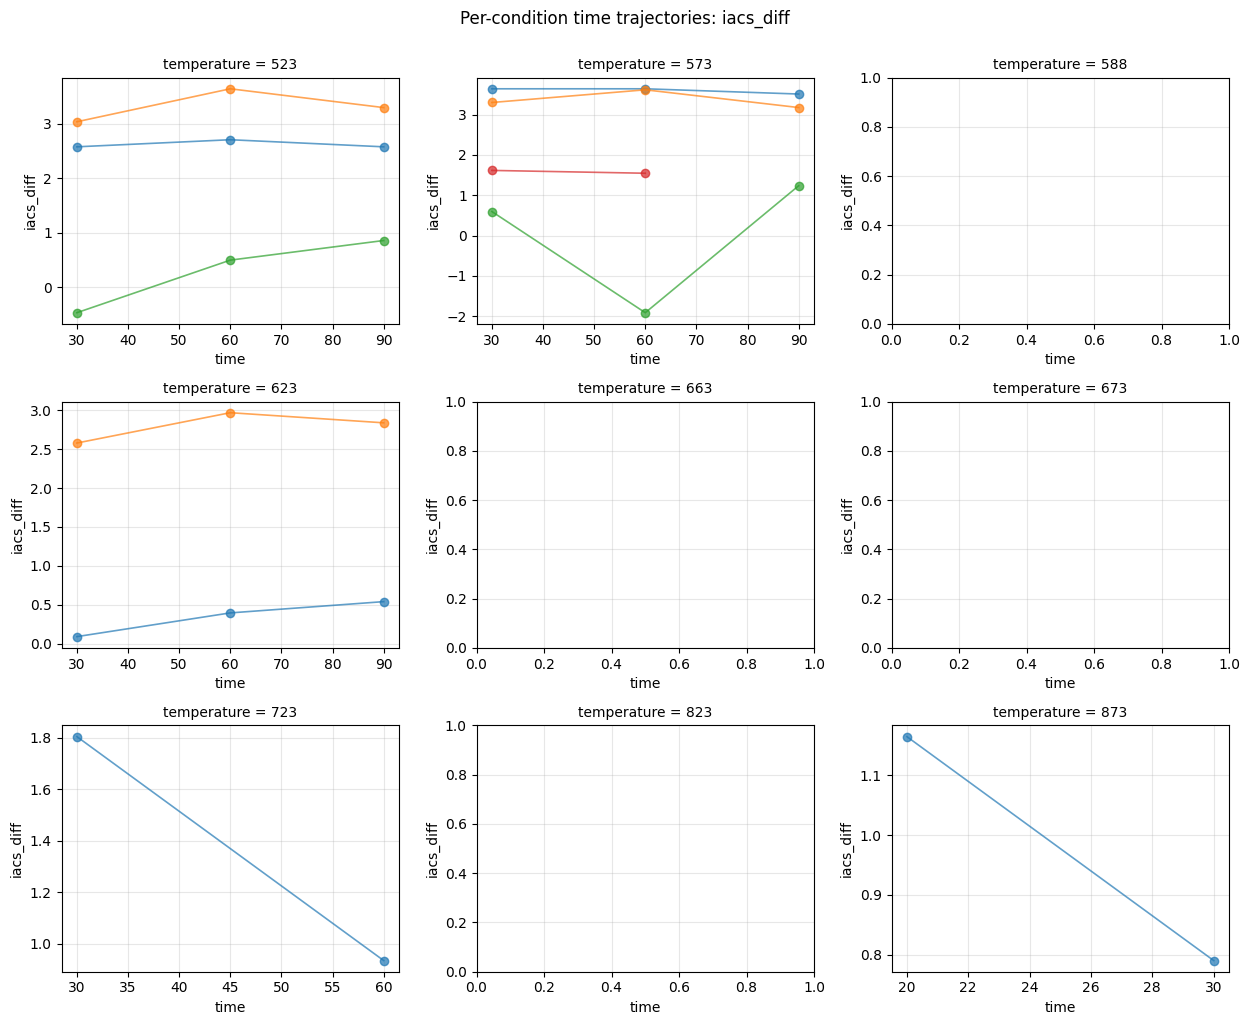

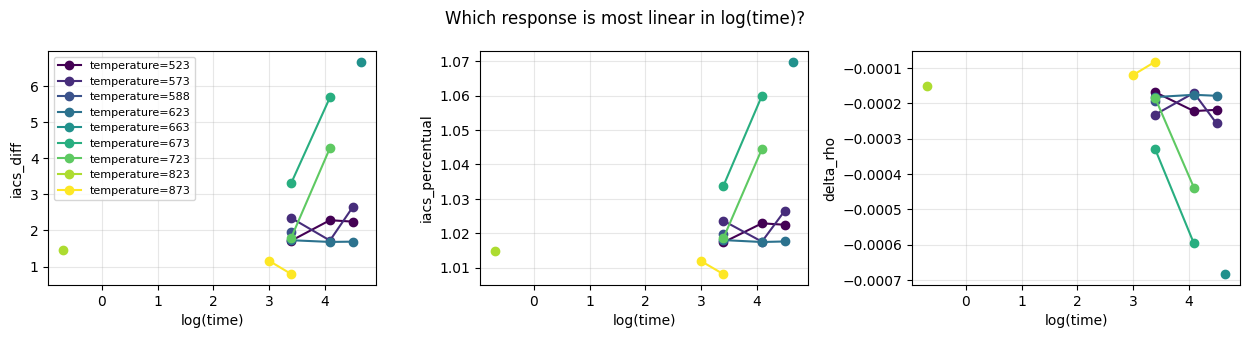

In [81]:
import importlib


# 1) Colunas derivadas (residual assinado, log_time, delta_rho de Matthiessen)
df_a = add_time_analysis_columns(df_analysis)

# 2) Estatística: Spearman + slope em log(time), POR temperatura
stats = time_trend_stats(df_a)
display(stats.round(4))

# 3) Observed vs expected — o surrogate reproduz a cinética?
fig1 = plot_observed_vs_expected(df_a, metric="iacs_diff")
fig1b = plot_observed_vs_expected(df_a, metric="iacs_percentual")

# 4) O diagnóstico principal: resíduo assinado vs tempo
fig2 = plot_residual_vs_time(df_a)

# 5) Trajetórias por condição (within-condition, sem mistura entre fios)
fig3 = plot_trajectories(df_a, metric="iacs_final")
fig3b = plot_trajectories(df_a, metric="iacs_diff")

# 6) Qual resposta é mais linear em log(time)?
fig4 = plot_metric_comparison(df_a)

In [92]:
df_analysis["temperature_C"] = df_analysis["temperature"] - 273

,n,iacs_diff_mean,iacs_diff_std,iacs_diff_expected_mean,iacs_diff_expected_std
time,,,,,
0.5,1,1.4550,0.0000,1.4274,0.0000
20.0,1,1.1650,0.0000,1.5209,0.0000
30.0,21,2.1425,1.1180,2.0002,0.9276
60.0,16,3.0322,2.2923,2.8516,1.8531
90.0,8,2.2550,1.1886,2.2921,1.5195
105.0,1,6.6850,0.0000,6.3160,0.0000


,n,iacs_diff_median,iacs_diff_q25,iacs_diff_q75,iacs_diff_expected_median,iacs_diff_expected_q25,iacs_diff_expected_q75
temperature_C,,,,,,,
250,9,2.5800,0.8600,3.0400,2.7021,0.7417,2.9027
300,17,2.5150,1.5600,3.3000,2.2921,1.6648,2.6923
315,1,1.9567,1.9567,1.9567,2.3529,2.3529,2.3529
350,7,2.5200,0.4675,2.7100,2.7461,0.6293,3.2207
390,1,6.6850,6.6850,6.6850,6.3160,6.3160,6.3160
400,3,3.6150,3.3200,4.6525,1.7526,1.5141,3.6400
450,7,4.2200,2.4875,5.2625,3.3253,2.1305,5.1477
550,1,1.4550,1.4550,1.4550,1.4274,1.4274,1.4274
600,2,0.9775,0.8838,1.0713,1.2368,1.0947,1.3788


,n,iacs_percentual_median,iacs_percentual_q25,iacs_percentual_q75,iacs_percentual_expected_median,iacs_percentual_expected_q25,iacs_percentual_expected_q75
time,,,,,,,
0.5,1,1.0149,1.0149,1.0149,1.0146,1.0146,1.0146
20.0,1,1.0119,1.0119,1.0119,1.0156,1.0156,1.0156
30.0,21,1.0252,1.0166,1.0286,1.0209,1.0165,1.0264
60.0,16,1.0341,1.0143,1.0460,1.0279,1.0172,1.0375
90.0,8,1.0277,1.0111,1.0317,1.0315,1.0073,1.0347
105.0,1,1.0699,1.0699,1.0699,1.0661,1.0661,1.0661


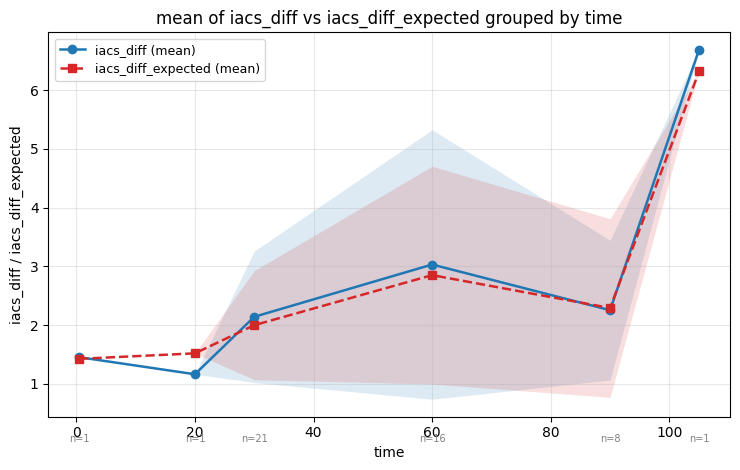

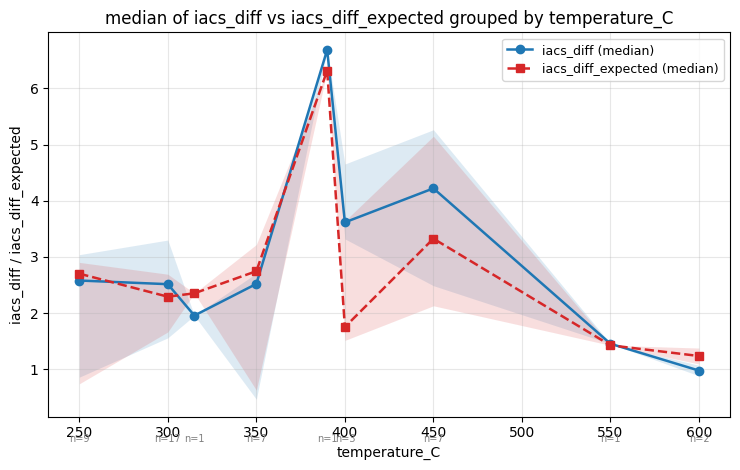

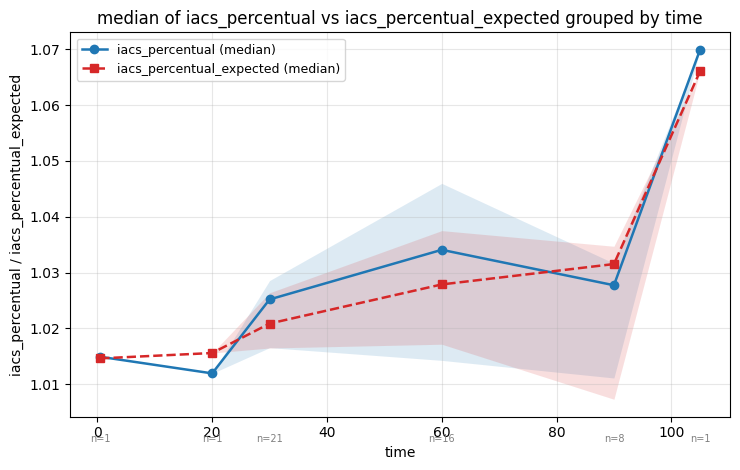

In [95]:

# x = time, observado vs esperado, média
fig, tbl = plot_grouped_response(
    df_analysis, x="time", y=["iacs_diff", "iacs_diff_expected"], agg="mean",
)
display(tbl.round(4))

# x = temperature, mesma dupla
fig, tbl = plot_grouped_response(
    df_analysis, x="temperature_C", y=["iacs_diff", "iacs_diff_expected"], agg="median",
)
display(tbl.round(4))

# versão percentual, mediana (mais robusta a outlier com n pequeno)
fig, tbl = plot_grouped_response(
    df_analysis, x="time",
    y=["iacs_percentual", "iacs_percentual_expected"], agg="median",
)
display(tbl.round(4))

In [88]:
"""Diagnostics for the time effect on annealing IACS.

Answers two distinct questions that are easy to conflate:

1. **Physics** — does annealing time move ``iacs_final``, and with what
   functional shape (linear? saturating in ``log(time)``?), once
   temperature is held fixed?
2. **Surrogate quality** — does the model *capture* that time effect? A
   signed residual that trends with time means the surrogate is missing
   time structure, regardless of how good its aggregate RMSE looks.

Temperature is a confounder for time in a crossed grid, so every plot
here is stratified by temperature. Aggregate ``time`` correlations
computed across temperatures are reported only as a deliberately
labelled "pooled (confounded)" row.

Matthiessen note
----------------
Scattering contributions add in resistivity, and IACS is inversely
proportional to resistivity. ``delta_rho = 1/iacs_final - 1/iacs`` is
therefore the physically additive counterpart of ``iacs_diff``; if the
time trend is cleaner in ``delta_rho`` than in ``iacs_diff``, that is
evidence the surrogate should see a resistivity-like feature rather
than a raw IACS delta.

Typical use
-----------
>>> df_a = add_time_analysis_columns(df_analysis)
>>> stats = time_trend_stats(df_a)
>>> fig1 = plot_observed_vs_expected(df_a)
>>> fig2 = plot_residual_vs_time(df_a)
"""

from __future__ import annotations

import logging
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

logger = logging.getLogger(__name__)

# Columns that are outputs/derived, never part of a "condition" identity.
_NON_CONDITION = {
    "time", "log_time", "iacs_final", "iacs_final_pred", "residual_abs",
    "residual_signed", "residual_rel", "iacs_percentual", "iacs_diff",
    "iacs_percentual_expected", "iacs_diff_expected", "delta_rho",
    "delta_rho_expected", "fold", "weight_col",
}


def add_time_analysis_columns(
    df: pd.DataFrame,
    target: str = "iacs_final",
    pred: str = "iacs_final_pred",
    initial: str = "iacs",
    time_col: str = "time",
) -> pd.DataFrame:
    """Add signed residual, log-time and Matthiessen resistivity deltas.

    Parameters
    ----------
    df : pd.DataFrame
        Frame already carrying ``iacs_diff`` / ``iacs_percentual`` and
        their ``_expected`` counterparts.
    target, pred, initial : str
        Observed target, model prediction, and pre-annealing IACS columns.
    time_col : str
        Annealing time column.

    Returns
    -------
    pd.DataFrame
        Copy of ``df`` with ``residual_signed``, ``residual_rel``,
        ``log_time``, ``delta_rho`` and ``delta_rho_expected``.

    Notes
    -----
    ``residual_signed`` (not ``residual_abs``) is the diagnostic column:
    absolute residuals destroy the sign of the bias, which is exactly
    the information needed to detect a missing time term.
    """
    out = df.copy()
    out["residual_signed"] = out[target] - out[pred]
    out["residual_rel"] = out["residual_signed"] / out[target]
    out["log_time"] = np.log(out[time_col].astype(float))

    # Matthiessen: scattering adds in resistivity, IACS ~ 1 / resistivity.
    out["delta_rho"] = 1.0 / out[target] - 1.0 / out[initial]
    out["delta_rho_expected"] = 1.0 / out[pred] - 1.0 / out[initial]

    logger.info(
        "Added time-analysis columns; n=%d, time range=[%s, %s], "
        "unique times=%d",
        len(out), out[time_col].min(), out[time_col].max(),
        out[time_col].nunique(),
    )
    return out


def infer_condition_columns(
    df: pd.DataFrame, extra_exclude: Sequence[str] = ()
) -> list[str]:
    """Infer the columns that identify one annealing condition.

    A "condition" is everything that is held fixed while time is swept:
    geometry, purity, IRI, initial IACS and temperature. Detected
    structurally (all columns minus known outputs/derived) so no target
    or feature name is hardcoded.

    Parameters
    ----------
    df : pd.DataFrame
        Analysis frame.
    extra_exclude : sequence of str
        Additional columns to treat as non-identity.

    Returns
    -------
    list[str]
        Condition-identifying columns, in frame order.
    """
    exclude = _NON_CONDITION | set(extra_exclude)
    cond = [c for c in df.columns if c not in exclude]
    logger.info("Inferred condition columns: %s", cond)
    return cond


def time_trend_stats(
    df: pd.DataFrame,
    metrics: Sequence[str] = (
        "iacs_final", "iacs_diff", "iacs_percentual", "delta_rho",
        "residual_signed",
    ),
    time_col: str = "time",
    group_col: str = "temperature",
) -> pd.DataFrame:
    """Per-temperature Spearman correlation and log-time OLS slope.

    Parameters
    ----------
    df : pd.DataFrame
        Output of :func:`add_time_analysis_columns`.
    metrics : sequence of str
        Columns to test against time.
    time_col, group_col : str
        Time column and stratification column.

    Returns
    -------
    pd.DataFrame
        One row per (group, metric) with ``n``, ``spearman``, ``p_value``
        and ``slope_log_time``. A final ``pooled (confounded)`` block
        repeats the test ignoring temperature, for contrast only.

    Notes
    -----
    With small per-temperature ``n``, treat ``p_value`` as a rough
    ordering device, not as a decision threshold. The sign and the
    consistency of the sign *across* temperatures carry more evidence
    than any single p-value.
    """
    from scipy import stats as sp_stats

    rows: list[dict] = []

    def _one(sub: pd.DataFrame, label: object, metric: str) -> dict:
        s = sub[[time_col, metric, "log_time"]].dropna()
        n = len(s)
        rho = p = slope = np.nan
        if n >= 3 and s[time_col].nunique() >= 2:
            rho, p = sp_stats.spearmanr(s[time_col], s[metric])
            slope = float(np.polyfit(s["log_time"], s[metric], 1)[0])
        return {
            group_col: label, "metric": metric, "n": n,
            "spearman": rho, "p_value": p, "slope_log_time": slope,
        }

    for label, sub in df.groupby(group_col, sort=True):
        for metric in metrics:
            if metric in df.columns:
                rows.append(_one(sub, label, metric))

    for metric in metrics:
        if metric in df.columns:
            rows.append(_one(df, "pooled (confounded)", metric))

    res = pd.DataFrame(rows)
    logger.info("Computed time-trend stats over %d rows.", len(res))
    return res


def plot_observed_vs_expected(
    df: pd.DataFrame,
    metric: str = "iacs_diff",
    expected_metric: str | None = None,
    time_col: str = "time",
    group_col: str = "temperature",
    figsize_per_panel: tuple[float, float] = (4.2, 3.4),
) -> plt.Figure:
    """Observed vs model-expected time response, one panel per temperature.

    Parameters
    ----------
    df : pd.DataFrame
        Output of :func:`add_time_analysis_columns`.
    metric : str
        Observed metric (e.g. ``iacs_diff`` or ``iacs_percentual``).
    expected_metric : str or None
        Model counterpart; defaults to ``f"{metric}_expected"``.
    time_col, group_col : str
        Time and stratification columns.
    figsize_per_panel : tuple of float
        Size of each subplot.

    Returns
    -------
    matplotlib.figure.Figure

    Notes
    -----
    Read the *gap* between the two curves, not their levels. Curves that
    track each other mean the surrogate reproduces the kinetics; a gap
    that widens with time means it does not.
    """
    exp_col = expected_metric or f"{metric}_expected"
    groups = sorted(df[group_col].dropna().unique())
    ncols = min(3, len(groups))
    nrows = int(np.ceil(len(groups) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, squeeze=False, sharex=True,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
    )

    for ax, label in zip(axes.ravel(), groups):
        sub = df[df[group_col] == label]
        obs = sub.groupby(time_col)[metric].agg(["mean", "std", "count"])
        ax.errorbar(
            obs.index, obs["mean"], yerr=obs["std"].fillna(0.0),
            marker="o", capsize=3, label="observed", color="#1f77b4",
        )
        if exp_col in sub.columns:
            exp = sub.groupby(time_col)[exp_col].mean()
            ax.plot(
                exp.index, exp.values, marker="s", linestyle="--",
                label="expected (model)", color="#d62728",
            )
        ax.set_title(f"{group_col} = {label}  (n={len(sub)})", fontsize=10)
        ax.set_xlabel(time_col)
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    for ax in axes.ravel()[len(groups):]:
        ax.set_visible(False)

    fig.suptitle(f"Time response: {metric} observed vs expected", y=1.0)
    fig.tight_layout()
    return fig


def plot_residual_vs_time(
    df: pd.DataFrame,
    residual_col: str = "residual_signed",
    time_col: str = "time",
    group_col: str = "temperature",
    figsize: tuple[float, float] = (11.0, 4.2),
) -> plt.Figure:
    """Signed residual against time — the key surrogate diagnostic.

    Left panel: scatter coloured by temperature with a per-temperature
    mean trace. Right panel: residual against ``log_time``, which
    reveals saturating kinetics that look like noise on a linear axis.

    Parameters
    ----------
    df : pd.DataFrame
        Output of :func:`add_time_analysis_columns`.
    residual_col, time_col, group_col : str
        Column names.
    figsize : tuple of float
        Figure size.

    Returns
    -------
    matplotlib.figure.Figure

    Notes
    -----
    A cloud centred on zero with no tilt at any temperature is the
    "model captured the kinetics" outcome. Any systematic tilt, or a
    tilt whose sign flips between temperatures, indicates a missing
    time--temperature interaction term.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    groups = sorted(df[group_col].dropna().unique())
    cmap = plt.get_cmap("viridis", max(len(groups), 2))

    for xcol, ax, xlabel in (
        (time_col, axes[0], time_col),
        ("log_time", axes[1], "log(time)"),
    ):
        for i, label in enumerate(groups):
            sub = df[df[group_col] == label]
            ax.scatter(
                sub[xcol], sub[residual_col], s=26, alpha=0.65,
                color=cmap(i), label=f"{group_col}={label}",
            )
            trace = sub.groupby(xcol)[residual_col].mean().sort_index()
            ax.plot(trace.index, trace.values, color=cmap(i), alpha=0.9)
        ax.axhline(0.0, color="black", linewidth=1.2, linestyle="--")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(residual_col)
        ax.grid(alpha=0.3)

    axes[0].legend(fontsize=8)
    fig.suptitle("Signed residual vs time (flat around 0 = time captured)")
    fig.tight_layout()
    return fig


def plot_trajectories(
    df: pd.DataFrame,
    metric: str = "iacs_final",
    time_col: str = "time",
    group_col: str = "temperature",
    condition_cols: Sequence[str] | None = None,
    min_points: int = 2,
    figsize_per_panel: tuple[float, float] = (4.2, 3.4),
) -> plt.Figure:
    """One line per annealing condition, showing its own time sweep.

    Parameters
    ----------
    df : pd.DataFrame
        Output of :func:`add_time_analysis_columns`.
    metric : str
        Column to trace over time.
    time_col, group_col : str
        Time and panel-stratification columns.
    condition_cols : sequence of str or None
        Identity of one condition; inferred via
        :func:`infer_condition_columns` when omitted.
    min_points : int
        Skip conditions with fewer than this many time points.
    figsize_per_panel : tuple of float
        Size of each subplot.

    Returns
    -------
    matplotlib.figure.Figure

    Notes
    -----
    This is the only view where within-condition change is not mixed
    with between-condition variation, so a trend visible here is far
    stronger evidence than one visible in a pooled scatter.
    """
    cond = list(condition_cols) if condition_cols else infer_condition_columns(df)
    cond_no_group = [c for c in cond if c != group_col]

    groups = sorted(df[group_col].dropna().unique())
    ncols = min(3, len(groups))
    nrows = int(np.ceil(len(groups) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, squeeze=False,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
    )

    n_traced = 0
    for ax, label in zip(axes.ravel(), groups):
        sub = df[df[group_col] == label]
        key = cond_no_group if cond_no_group else None
        iterator = sub.groupby(key, sort=False) if key else [(None, sub)]
        for _, traj in iterator:
            traj = traj.sort_values(time_col)
            if len(traj) < min_points:
                continue
            ax.plot(
                traj[time_col], traj[metric], marker="o", alpha=0.7,
                linewidth=1.2,
            )
            n_traced += 1
        ax.set_title(f"{group_col} = {label}", fontsize=10)
        ax.set_xlabel(time_col)
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)

    for ax in axes.ravel()[len(groups):]:
        ax.set_visible(False)

    logger.info("Traced %d conditions with >= %d time points.", n_traced, min_points)
    fig.suptitle(f"Per-condition time trajectories: {metric}", y=1.0)
    fig.tight_layout()
    return fig


def plot_metric_comparison(
    df: pd.DataFrame,
    metrics: Sequence[str] = ("iacs_diff", "iacs_percentual", "delta_rho"),
    time_col: str = "time",
    group_col: str = "temperature",
    figsize_per_panel: tuple[float, float] = (4.2, 3.4),
) -> plt.Figure:
    """Compare candidate response variables against ``log(time)``.

    Whichever metric is closest to a straight line in ``log(time)``, with
    consistent slope across temperatures, is the best-behaved response
    for the surrogate to learn.

    Parameters
    ----------
    df : pd.DataFrame
        Output of :func:`add_time_analysis_columns`.
    metrics : sequence of str
        Candidate response columns.
    time_col, group_col : str
        Column names.
    figsize_per_panel : tuple of float
        Size of each subplot.

    Returns
    -------
    matplotlib.figure.Figure
    """
    metrics = [m for m in metrics if m in df.columns]
    groups = sorted(df[group_col].dropna().unique())
    cmap = plt.get_cmap("viridis", max(len(groups), 2))
    fig, axes = plt.subplots(
        1, len(metrics), squeeze=False,
        figsize=(figsize_per_panel[0] * len(metrics), figsize_per_panel[1]),
    )

    for ax, metric in zip(axes.ravel(), metrics):
        for i, label in enumerate(groups):
            sub = df[df[group_col] == label]
            trace = sub.groupby("log_time")[metric].mean().sort_index()
            ax.plot(
                trace.index, trace.values, marker="o", color=cmap(i),
                label=f"{group_col}={label}",
            )
        ax.set_xlabel("log(time)")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.3)
    axes.ravel()[0].legend(fontsize=8)
    fig.suptitle("Which response is most linear in log(time)?")
    fig.tight_layout()
    return fig


def plot_grouped_response(
    df: pd.DataFrame,
    x: str = "time",
    y: str | Sequence[str] = "iacs_diff",
    agg: str = "mean",
    spread: str | None = "auto",
    annotate_counts: bool = True,
    ax: plt.Axes | None = None,
    figsize: tuple[float, float] = (7.5, 4.8),
    colors: Sequence[str] = ("#1f77b4", "#d62728"),
) -> tuple[plt.Figure, pd.DataFrame]:
    """Aggregate one or two same-dimension columns over ``x`` and plot them.

    The chosen ``x`` (typically ``time`` or ``temperature``) becomes the
    horizontal axis; every row sharing an ``x`` value is collapsed with
    ``agg`` into a single point per curve. Intended for comparing an
    observed column against its model counterpart (e.g. ``iacs_diff``
    vs ``iacs_diff_expected``), which share units and therefore share
    one vertical axis.

    Parameters
    ----------
    df : pd.DataFrame
        Analysis frame.
    x : str
        Grouping column plotted on the horizontal axis.
    y : str or sequence of str
        One or two columns to aggregate. Must share physical units.
    agg : {'mean', 'median'}
        Central-tendency statistic applied within each ``x`` group.
    spread : {'auto', 'std', 'sem', 'iqr', None}
        Shaded band around each curve. ``'auto'`` picks ``'std'`` for
        ``mean`` and ``'iqr'`` for ``median``. ``None`` disables it.
    annotate_counts : bool
        Print the group size under each x tick.
    ax : matplotlib.axes.Axes or None
        Draw into an existing axis when provided.
    figsize : tuple of float
        Figure size when ``ax`` is None.
    colors : sequence of str
        Line colours, one per y column.

    Returns
    -------
    fig : matplotlib.figure.Figure
    table : pd.DataFrame
        Indexed by ``x``, with ``<col>_<agg>``, the spread column and
        ``n`` per group.

    Notes
    -----
    Collapsing over every other column marginalises them. If the grid is
    unbalanced -- different temperatures represented at different times,
    or more replicates at some settings -- the marginal curve mixes those
    compositions and part of the apparent ``x`` trend is composition,
    not physics. The ``n`` annotation exists to make that visible; if the
    counts are uneven, cross-check against the per-temperature panels
    before drawing conclusions.
    """
    if agg not in ("mean", "median"):
        raise ValueError(f"agg must be 'mean' or 'median', got {agg!r}.")
    y_cols = [y] if isinstance(y, str) else list(y)
    if not 1 <= len(y_cols) <= 2:
        raise ValueError(f"Pass one or two y columns, got {len(y_cols)}.")
    missing = [c for c in [x, *y_cols] if c not in df.columns]
    if missing:
        raise KeyError(f"Columns {missing} not in df (have {list(df.columns)}).")

    if spread == "auto":
        spread = "std" if agg == "mean" else "iqr"

    grouped = df.groupby(x, sort=True)
    table = pd.DataFrame(index=grouped.size().index)
    table["n"] = grouped.size()

    fig = ax.get_figure() if ax is not None else plt.figure(figsize=figsize)
    ax = ax if ax is not None else fig.add_subplot(111)

    for i, col in enumerate(y_cols):
        centre = grouped[col].agg(agg)
        table[f"{col}_{agg}"] = centre
        colour = colors[i % len(colors)]
        style = "-" if i == 0 else "--"
        ax.plot(
            centre.index, centre.to_numpy(), marker="o" if i == 0 else "s",
            linestyle=style, color=colour, linewidth=1.8, label=f"{col} ({agg})",
        )

        if spread == "std":
            band = grouped[col].std().fillna(0.0)
            lo, hi = centre - band, centre + band
            table[f"{col}_std"] = band
        elif spread == "sem":
            band = (grouped[col].std() / np.sqrt(grouped[col].count())).fillna(0.0)
            lo, hi = centre - band, centre + band
            table[f"{col}_sem"] = band
        elif spread == "iqr":
            lo = grouped[col].quantile(0.25)
            hi = grouped[col].quantile(0.75)
            table[f"{col}_q25"] = lo
            table[f"{col}_q75"] = hi
        else:
            lo = hi = None

        if lo is not None:
            ax.fill_between(
                centre.index, lo.to_numpy(), hi.to_numpy(),
                color=colour, alpha=0.15, linewidth=0,
            )

    if annotate_counts:
        ymin = ax.get_ylim()[0]
        for xv, n in table["n"].items():
            ax.annotate(
                f"n={n}", xy=(xv, ymin), xytext=(0, -18),
                textcoords="offset points", ha="center", fontsize=7,
                color="gray", annotation_clip=False,
            )

    ax.set_xlabel(x)
    ax.set_ylabel(" / ".join(y_cols))
    ax.set_title(f"{agg} of {' vs '.join(y_cols)} grouped by {x}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()

    logger.info(
        "Grouped %d rows by '%s' into %d points (agg=%s, spread=%s).",
        len(df), x, len(table), agg, spread,
    )
    return fig, table

In [94]:
df_analysis

,initial_diameter,IRI,purity,iacs,temperature,time,iacs_final,iacs_final_pred,residual_abs,iacs_percentual,iacs_diff,iacs_percentual_expected,iacs_diff_expected,temperature_C
0,1.900000,1.300000,99.9000,88.260,623,30.0,88.350000,88.746994,0.396994,1.001020,0.090000,1.005518,0.486994,350
1,1.900000,1.300000,99.9000,88.260,623,60.0,88.655000,88.790726,0.135726,1.004475,0.395000,1.006013,0.530726,350
2,1.900000,1.300000,99.9000,88.260,623,90.0,88.800000,88.987961,0.187961,1.006118,0.540000,1.008248,0.727961,350
3,2.160000,0.195105,99.9000,99.825,573,30.0,102.340000,102.117134,0.222866,1.025194,2.515000,1.022962,2.292134,300
4,2.182333,0.195105,99.9000,99.390,573,30.0,102.230000,101.442055,0.787945,1.028574,2.840000,1.020646,2.052055,300
5,2.182333,0.195105,99.9000,99.390,588,30.0,101.346667,101.742882,0.396215,1.019687,1.956667,1.023673,2.352882,315
6,2.191700,0.195105,99.9000,99.230,573,30.0,101.355000,101.300667,0.054333,1.021415,2.125000,1.020867,2.070667,300
7,2.196300,0.195105,99.9000,98.720,573,30.0,101.480000,101.244438,0.235562,1.027958,2.760000,1.025572,2.524438,300
8,1.200000,0.233275,99.9000,97.710,523,30.0,100.290000,99.998184,0.291816,1.026405,2.580000,1.023418,2.288184,250
9,1.200000,0.233275,99.9000,97.710,523,60.0,100.420000,100.412086,0.007914,1.027735,2.710000,1.027654,2.702086,250
